#Demand Forecasting Pipeline
####Setting up basics

In [2]:
import numpy as np
import pandas as pd
import pandasql as ps
import math
import itertools 
from scipy import stats
import time
import logging

# Set logging level for cmdstanpy to ERROR
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
#matplotlib libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
import seaborn as sns

#date libraries
from dateutil import parser
from datetime import datetime, timedelta, date
import holidays

#prophet library
from prophet import Prophet
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.diagnostics import cross_validation

#pandas options
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#matplotlib setting defaults
sns.set(font="Arial",
        rc={
 "axes.axisbelow": False,
 "axes.edgecolor": "lightgrey",
 "axes.facecolor": "None",
 "axes.grid": False,
 "axes.labelcolor": "dimgrey",
 "axes.spines.right": False,
 "axes.spines.top": False,
 "figure.facecolor": "white",
 "lines.solid_capstyle": "round",
 "patch.edgecolor": "w",
 "patch.force_edgecolor": True,
 "text.color": "dimgrey",
 "xtick.bottom": False,
 "xtick.color": "dimgrey",
 "xtick.direction": "out",
 "xtick.top": False,
 "ytick.color": "dimgrey",
 "ytick.direction": "out",
 "ytick.left": False,
 "ytick.right": False})

In [3]:
def missing_data(input_data):
    '''
    This function returns dataframe with information about the percentage of nulls in each column and the column data type.
    
    input: pandas df
    output: pandas df
    
    '''
    
    total = input_data.isnull().sum()
    percent = (input_data.isnull().sum()/input_data.isnull().count()*100)
    table = pd.concat([total, percent], axis = 1, keys = ['Total', 'Percent'])
    types = []
    for col in input_data.columns: 
        dtype = str(input_data[col].dtype)
        types.append(dtype)
    table["Types"] = types
    return(pd.DataFrame(table))

def mape(actual, pred): 
    '''
    Mean Absolute Percentage Error (MAPE) Function
    
    input: list/series for actual values and predicted values
    output: mape value 
    '''
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100

### Read Data
#### Sales dataset from kaggle from Corporación Favorita, a large Ecuadorian-based grocery retailer. (ref: https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data?select=train.csv)

In [4]:
df = pd.read_csv('store-sales-time-series-forecasting/train.csv')
df.columns = df.columns.str.replace(' ', '_').str.lower()

df['date'] = pd.to_datetime(df['date'])

In [5]:
min(df['date']), max(df['date'])

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [6]:
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0


In [7]:
agg_df = df.groupby(['date','family']).agg({'sales':'sum'}).reset_index().sort_values(['family','date'])

In [8]:
agg_df.head()

,date,family,sales
0,2013-01-01,AUTOMOTIVE,0.00
33,2013-01-02,AUTOMOTIVE,255.00
66,2013-01-03,AUTOMOTIVE,161.00
99,2013-01-04,AUTOMOTIVE,169.00
132,2013-01-05,AUTOMOTIVE,342.00


###Plot an overview of how the data trends and distributions look over time for different product categories.

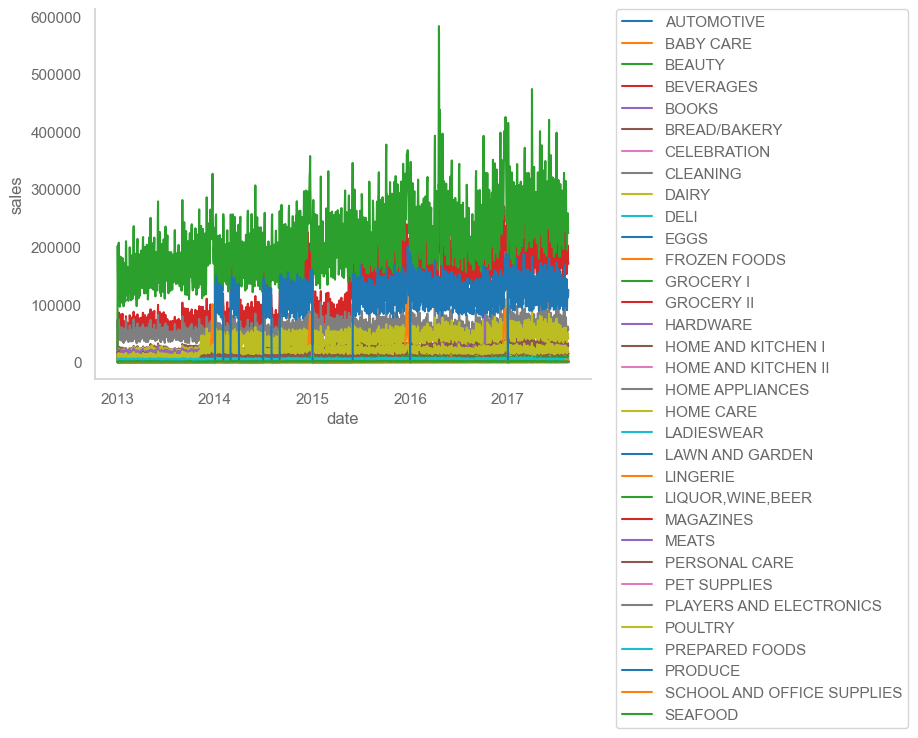

In [9]:
sns.lineplot(data=agg_df, x='date', y='sales', hue='family', palette='tab10')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [10]:
total_sales_df = agg_df.pivot(index = 'date', columns='family', values='sales')
total_sales_df.head()

family,AUTOMOTIVE,BABY CARE,BEAUTY,BEVERAGES,BOOKS,BREAD/BAKERY,CELEBRATION,CLEANING,DAIRY,DELI,EGGS,FROZEN FOODS,GROCERY I,GROCERY II,HARDWARE,HOME AND KITCHEN I,HOME AND KITCHEN II,HOME APPLIANCES,HOME CARE,LADIESWEAR,LAWN AND GARDEN,LINGERIE,"LIQUOR,WINE,BEER",MAGAZINES,MEATS,PERSONAL CARE,PET SUPPLIES,PLAYERS AND ELECTRONICS,POULTRY,PREPARED FOODS,PRODUCE,SCHOOL AND OFFICE SUPPLIES,SEAFOOD
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.00,0.00,2.00,810.00,0.00,180.59,0.00,186.00,143.00,71.09,46.00,29.65,700.00,15.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,5.00,105.00,0.00,110.80,25.00,0.00,0.00,42.64,37.85,0.00,0.00,0.00
2013-01-02,255.00,0.00,207.00,72092.00,0.00,26246.32,0.00,74629.00,23381.00,15754.50,10932.00,7115.39,202020.00,1476.00,46.00,0.00,0.00,21.00,0.00,0.00,121.00,469.00,2411.00,0.00,20871.46,17204.00,0.00,0.00,13975.88,5338.11,0.00,0.00,1526.75
2013-01-03,161.00,0.00,125.00,52105.00,0.00,18456.48,0.00,55893.00,18001.00,11172.45,7358.00,4760.81,144878.00,1048.00,37.00,0.00,0.00,15.00,0.00,0.00,83.00,366.00,2476.00,0.00,16597.40,12568.00,0.00,0.00,10674.39,3591.39,0.00,0.00,1094.31
2013-01-04,169.00,0.00,133.00,54167.00,0.00,16721.97,0.00,52064.00,18148.00,10143.21,6760.00,4525.93,135754.00,1031.00,57.00,0.00,0.00,13.00,0.00,0.00,127.00,382.00,4796.00,0.00,21625.96,11303.00,0.00,0.00,10772.52,4472.97,0.00,0.00,1293.12
2013-01-05,342.00,0.00,191.00,77818.00,0.00,22367.76,0.00,70128.00,23082.00,13734.95,8576.00,5781.61,188356.00,1273.00,87.00,0.00,0.00,11.00,0.00,0.00,180.00,458.00,6715.00,0.00,20879.09,16819.00,0.00,0.00,13475.01,5830.07,0.00,0.00,1245.64


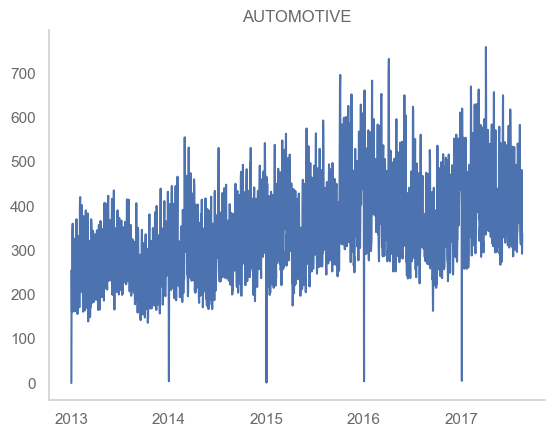

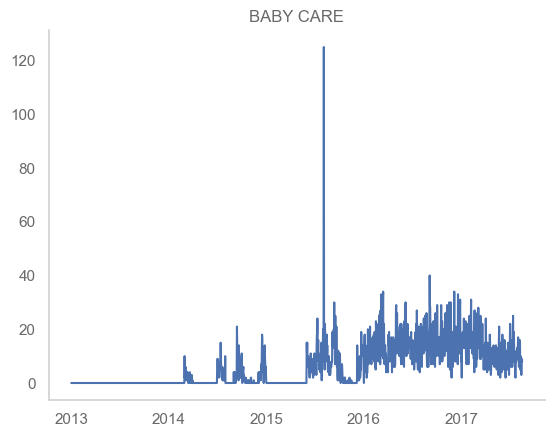

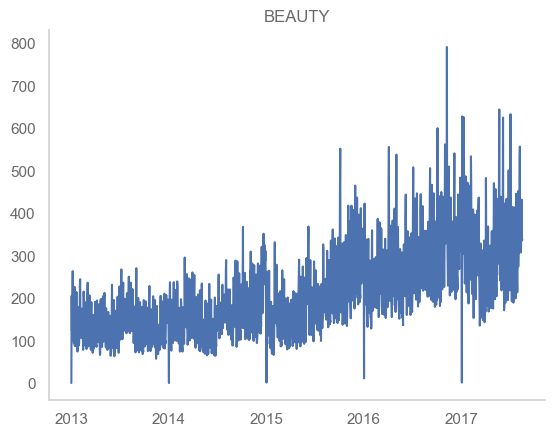

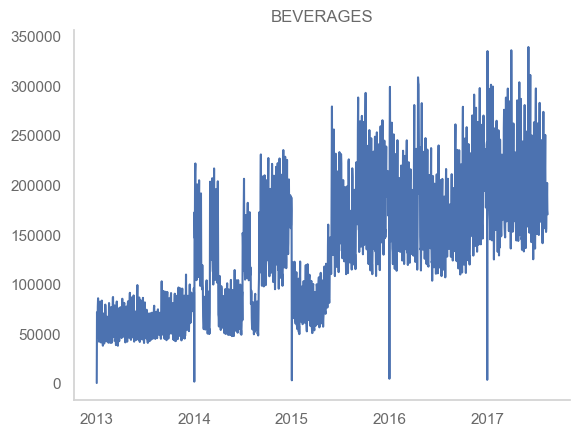

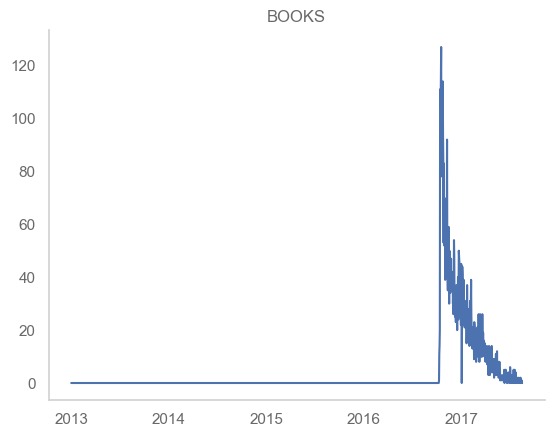

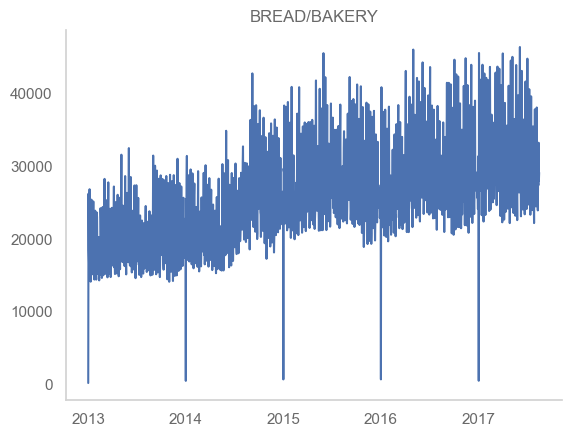

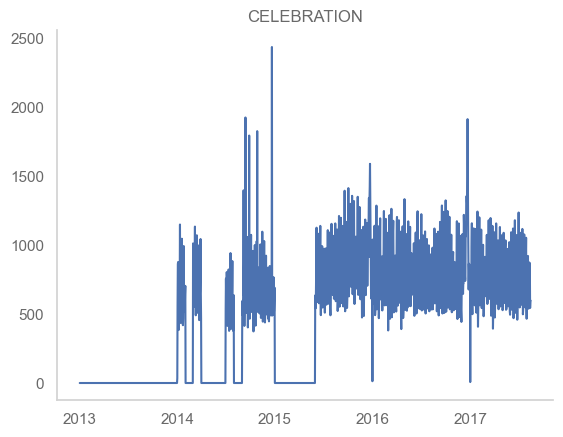

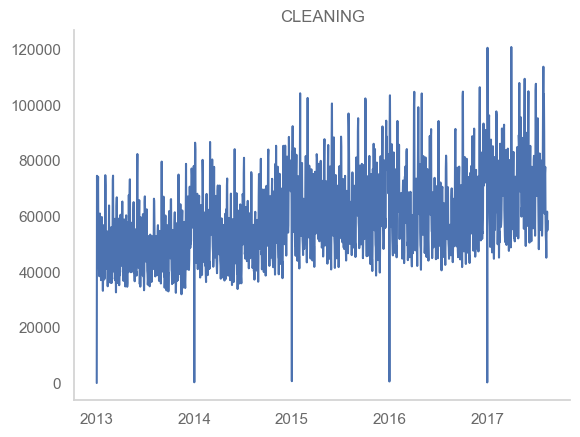

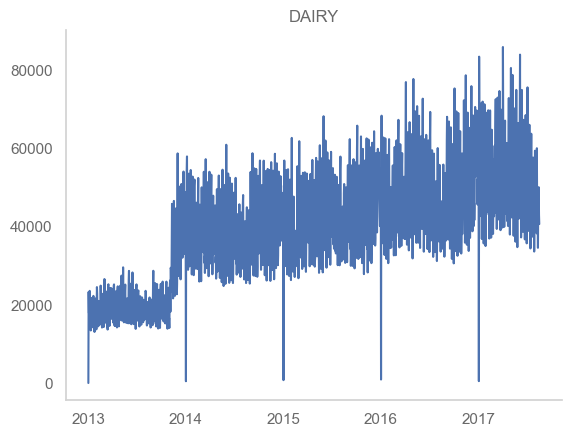

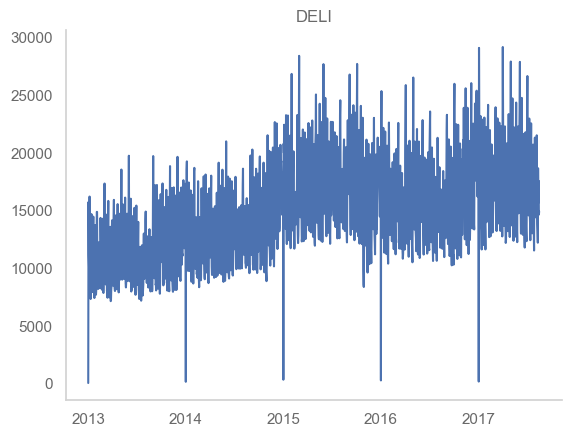

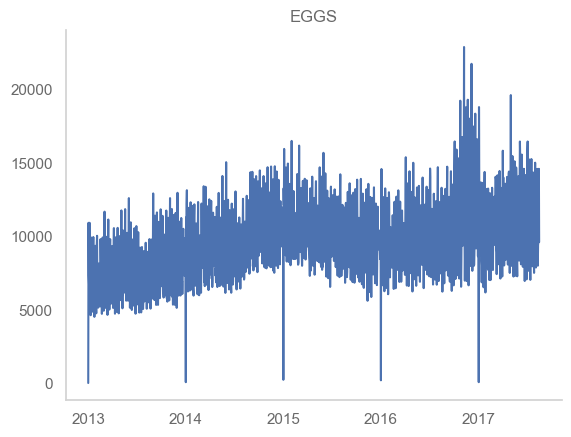

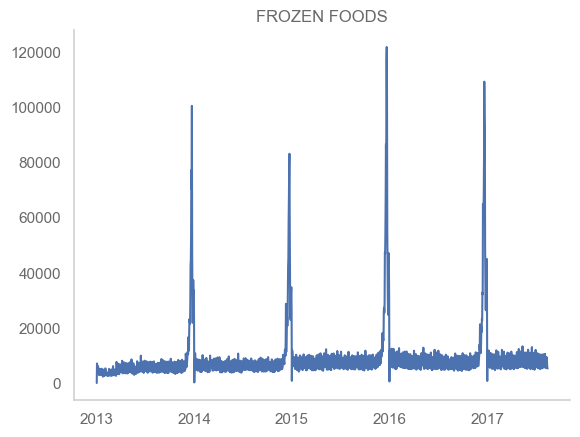

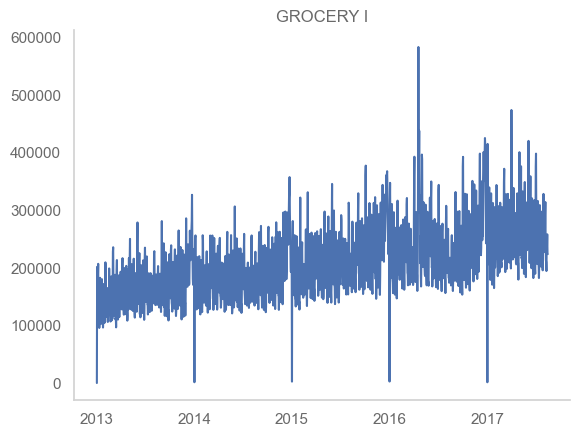

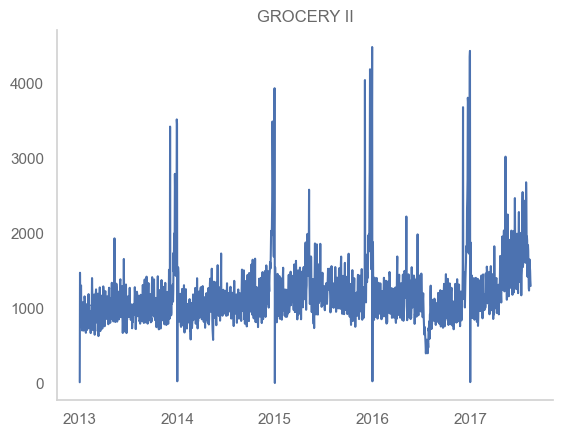

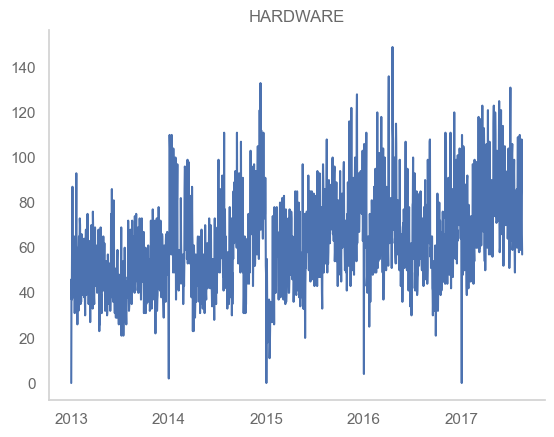

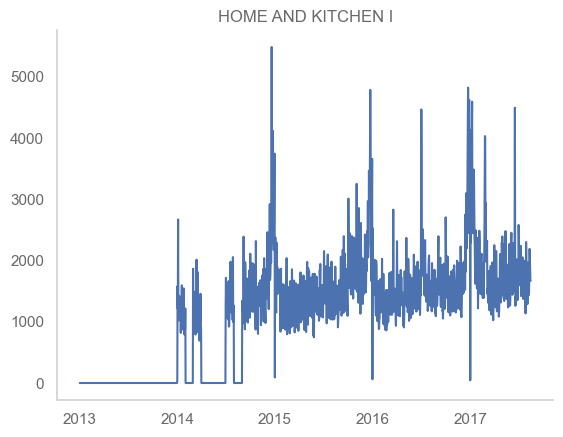

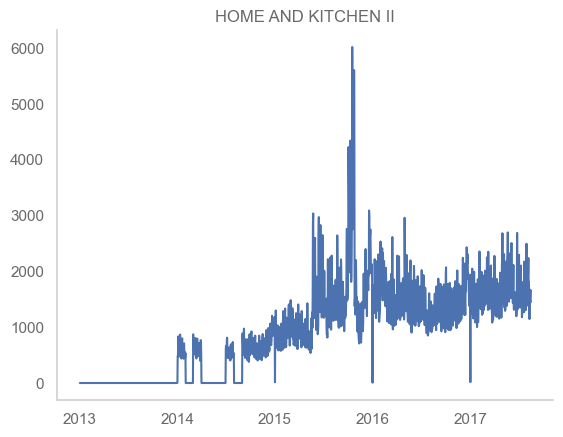

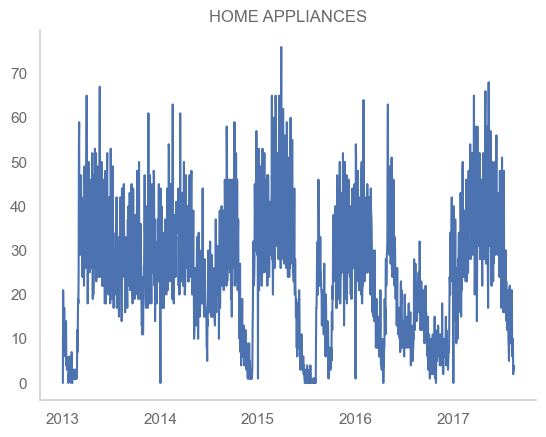

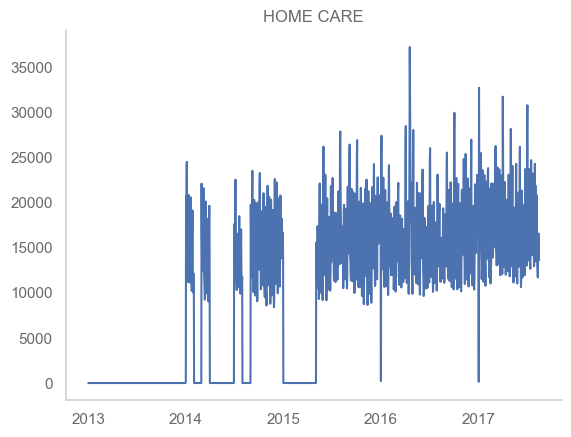

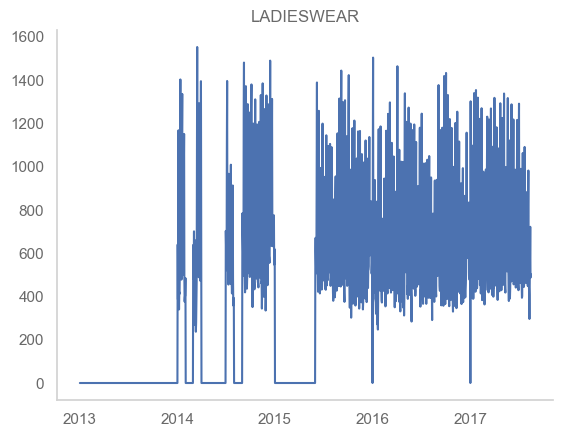

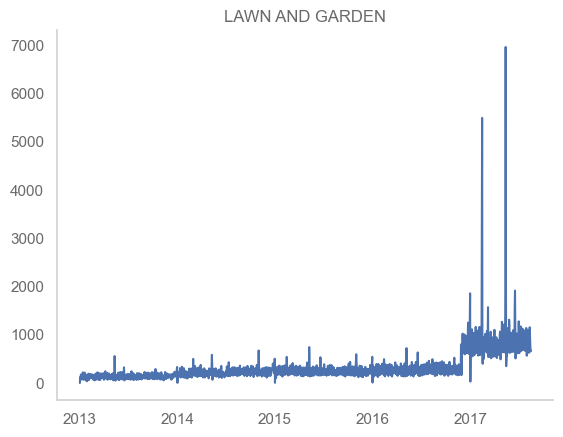

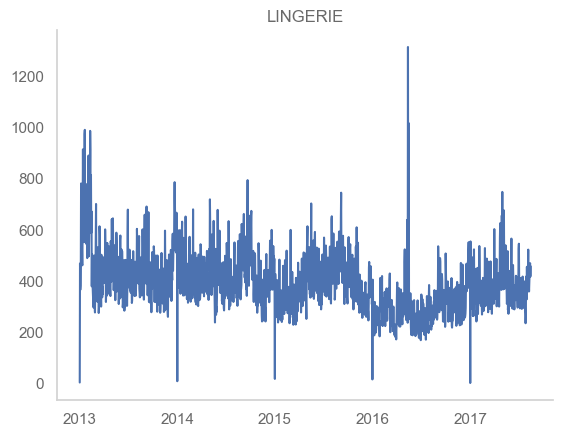

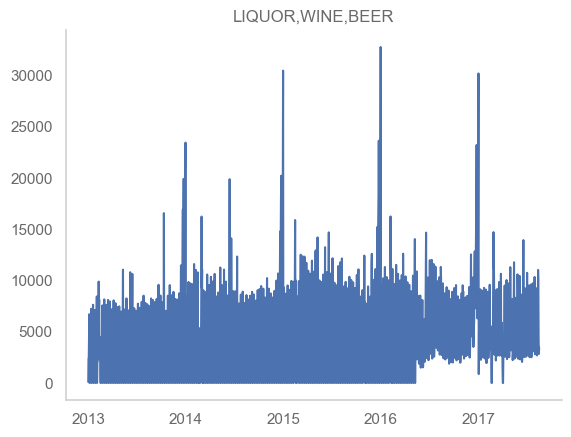

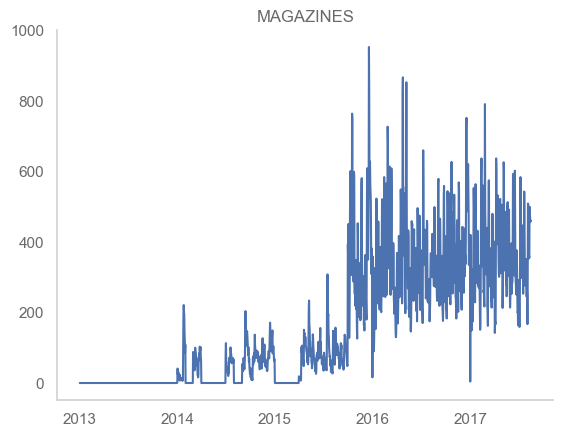

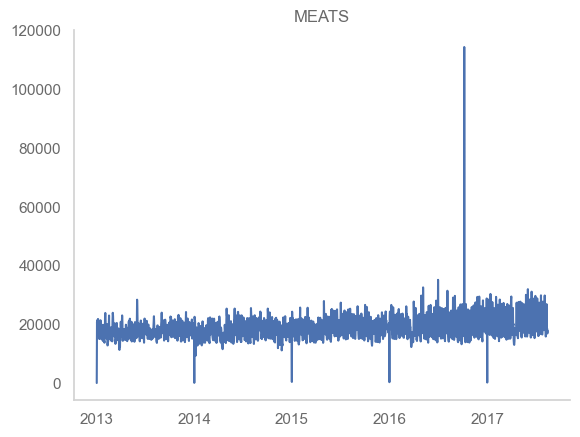

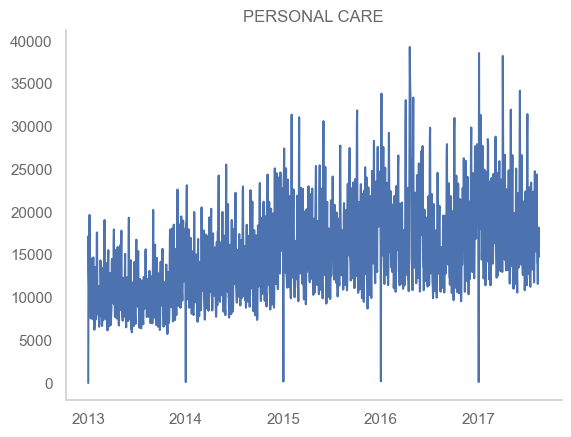

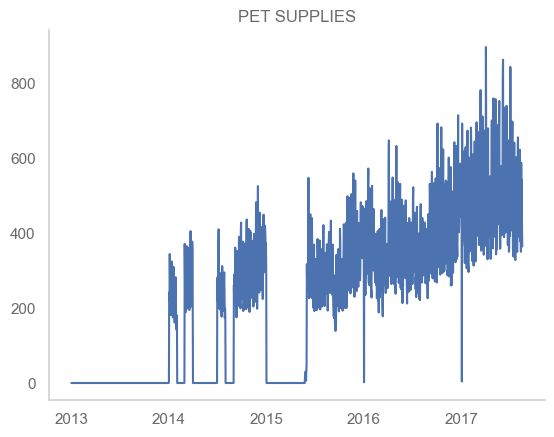

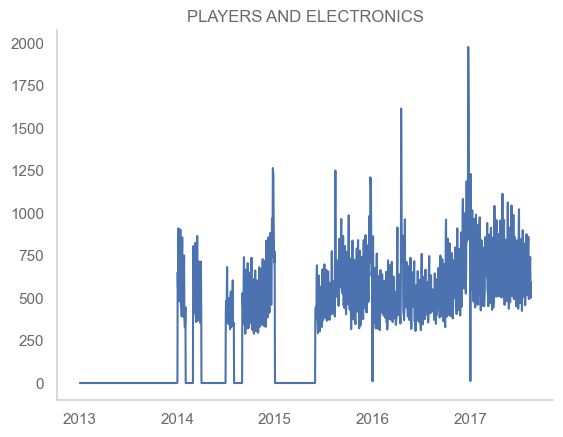

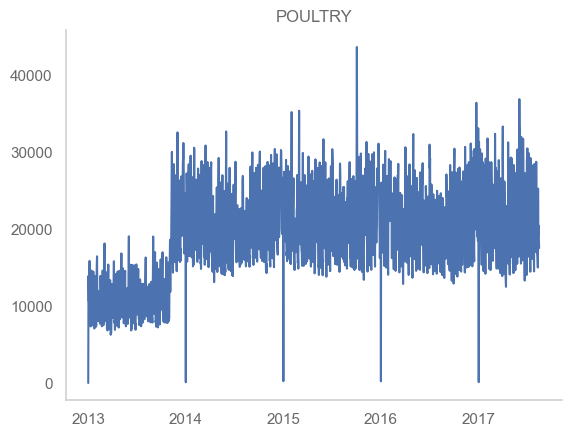

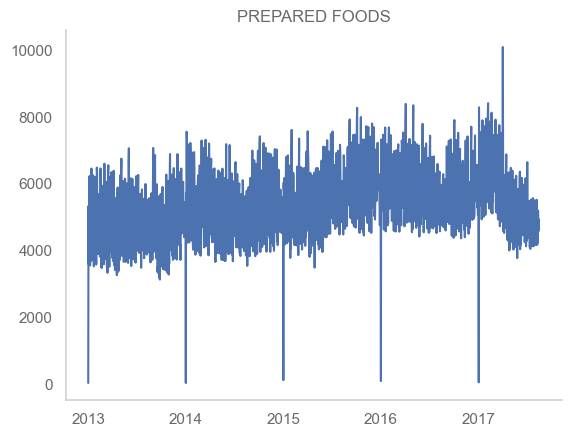

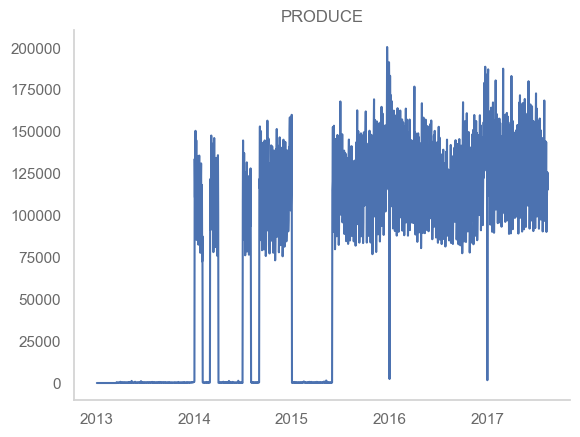

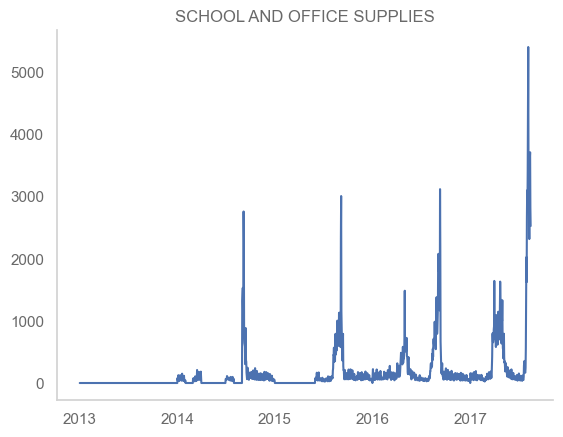

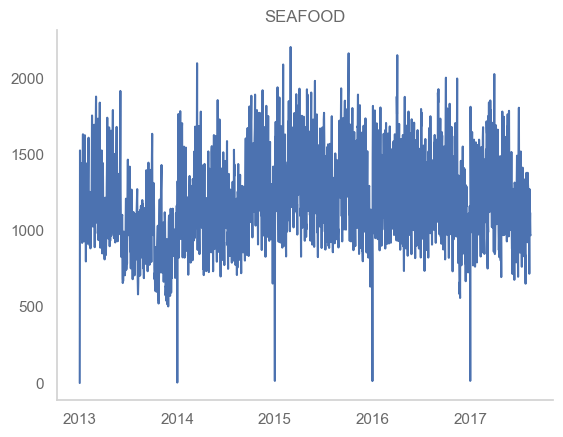

In [11]:
for column in total_sales_df.columns:
    plt.plot(total_sales_df[column])
    plt.title(column)
    plt.show()

In [12]:
total_sales_df = total_sales_df[total_sales_df.index>='2015-08-15']

In [13]:
missing_data(total_sales_df)

,Total,Percent,Types
family,,,
AUTOMOTIVE,0,0.00,float64
BABY CARE,0,0.00,float64
BEAUTY,0,0.00,float64
BEVERAGES,0,0.00,float64
BOOKS,0,0.00,float64
BREAD/BAKERY,0,0.00,float64
CELEBRATION,0,0.00,float64
CLEANING,0,0.00,float64
DAIRY,0,0.00,float64


###Data Cleaning 
1. Remove low-volume data that can't be predicted.
2. Remove situations where there's not enough data. (i.e. by visual inspection or by number of '0' daily sales counts.
3. Remove outliers (automated by calculating z-score and just removing it and having Prophet impute those values). This will remove the outliers near 0 for all categories.
4. Check if more data needs to be removed after filtering to 08/15/15 - 08/15/17. If not, then we can move throughout the pipeline.

In [14]:
old_len = len(total_sales_df.columns)
print(old_len)
total_sales_df = total_sales_df[total_sales_df.columns[total_sales_df.apply(np.mean,axis='rows') > 1000]]
print(len(total_sales_df.columns))
print("Dropping "+ str(old_len-len(total_sales_df.columns))+" columns due to insufficient data volume.")

33
19
Dropping 14 columns due to insufficient data volume.


In [15]:
#Get percentage of rows for each category that is at 0
percentage_zeros = (total_sales_df == 0).astype(int).sum(axis=0) / len(total_sales_df) * 100
print(percentage_zeros)

family
BEVERAGES             0.00
BREAD/BAKERY          0.00
CLEANING              0.00
DAIRY                 0.00
DELI                  0.00
EGGS                  0.00
FROZEN FOODS          0.00
GROCERY I             0.00
GROCERY II            0.00
HOME AND KITCHEN I    0.00
HOME AND KITCHEN II   0.00
HOME CARE             0.00
LIQUOR,WINE,BEER      5.75
MEATS                 0.00
PERSONAL CARE         0.00
POULTRY               0.00
PREPARED FOODS        0.00
PRODUCE               0.00
SEAFOOD               0.00
dtype: float64


In [16]:
print(total_sales_df.columns)

Index(['BEVERAGES', 'BREAD/BAKERY', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HOME AND KITCHEN I',
       'HOME AND KITCHEN II', 'HOME CARE', 'LIQUOR,WINE,BEER', 'MEATS',
       'PERSONAL CARE', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SEAFOOD'],
      dtype='object', name='family')


In [17]:
prediction_df_list = []
#Cleaning up dataframe using z-score to remove outliers which heavily bias the model
for column in total_sales_df.columns:
    df_clean = total_sales_df[[column]].reset_index()
    z = np.abs(stats.zscore(df_clean[column]))
    outlier_index = np.where(z>2.5)[0]
    print("Dropping "+str(len(outlier_index))+" rows for following category: "+column)
    df_clean.drop(index = outlier_index,inplace = True)
    df_clean.set_index('date', inplace=True)
    # df_clean = df_clean.interpolate(method='linear')
    df_clean = df_clean.ffill()
    # df_clean = df_clean.bfill()
    prediction_df_list.append(df_clean)


Dropping 17 rows for following category: BEVERAGES
Dropping 19 rows for following category: BREAD/BAKERY
Dropping 19 rows for following category: CLEANING
Dropping 16 rows for following category: DAIRY
Dropping 13 rows for following category: DELI
Dropping 13 rows for following category: EGGS
Dropping 23 rows for following category: FROZEN FOODS
Dropping 19 rows for following category: GROCERY I
Dropping 16 rows for following category: GROCERY II
Dropping 25 rows for following category: HOME AND KITCHEN I
Dropping 18 rows for following category: HOME AND KITCHEN II
Dropping 16 rows for following category: HOME CARE
Dropping 14 rows for following category: LIQUOR,WINE,BEER
Dropping 4 rows for following category: MEATS
Dropping 17 rows for following category: PERSONAL CARE
Dropping 5 rows for following category: POULTRY
Dropping 8 rows for following category: PREPARED FOODS
Dropping 7 rows for following category: PRODUCE
Dropping 6 rows for following category: SEAFOOD


In [18]:
combined_df = pd.concat(prediction_df_list, axis=1)

In [19]:
combined_df = combined_df.dropna()
missing_data(combined_df)

,Total,Percent,Types
family,,,
BEVERAGES,0,0.00,float64
BREAD/BAKERY,0,0.00,float64
CLEANING,0,0.00,float64
DAIRY,0,0.00,float64
DELI,0,0.00,float64
EGGS,0,0.00,float64
FROZEN FOODS,0,0.00,float64
GROCERY I,0,0.00,float64
GROCERY II,0,0.00,float64


In [20]:
print(combined_df.head())

family      BEVERAGES  BREAD/BAKERY  CLEANING    DAIRY     DELI     EGGS  \
date                                                                       
2015-08-15  217135.00      32509.91  75837.00 48578.00 19946.92 11232.00   
2015-08-16  208213.00      34851.88  75824.00 50930.00 21178.46 11977.00   
2015-08-17  149741.00      26361.77  59718.00 38358.00 15755.02 10713.00   
2015-08-18  132609.00      23915.95  52749.00 33273.00 14119.25  8123.00   
2015-08-19  131368.00      23995.15  51157.00 35760.00 13250.04  8001.00   

family      FROZEN FOODS  GROCERY I  GROCERY II  HOME AND KITCHEN I  \
date                                                                  
2015-08-15      10075.02  280491.48     1552.00             1899.00   
2015-08-16       7526.03  266657.28     1441.00             1418.00   
2015-08-17       5145.30  205150.61     1161.00             1143.00   
2015-08-18       5050.99  181016.01      955.00             1181.00   
2015-08-19       5372.18  178550.63     1

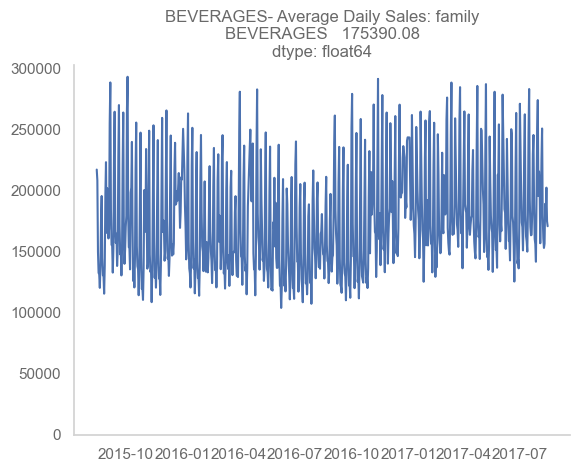

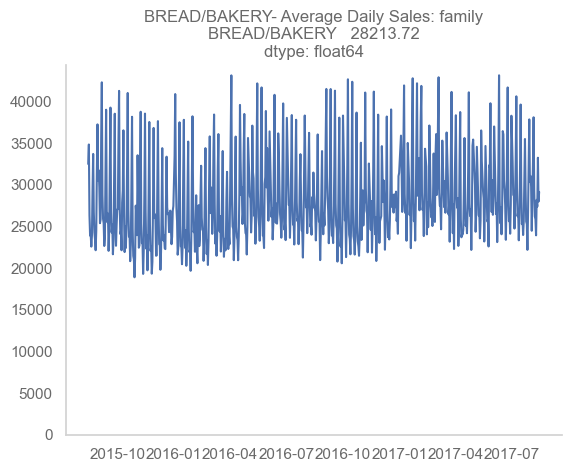

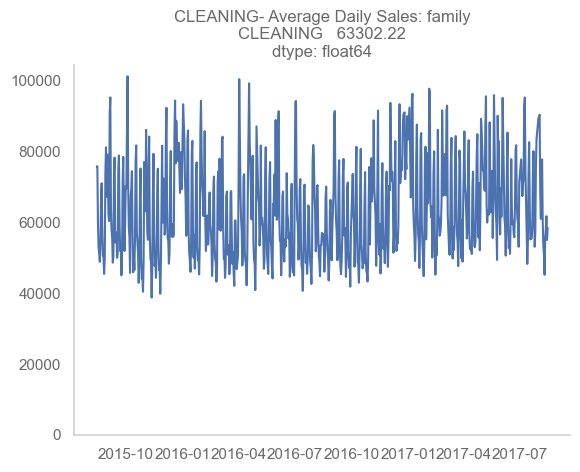

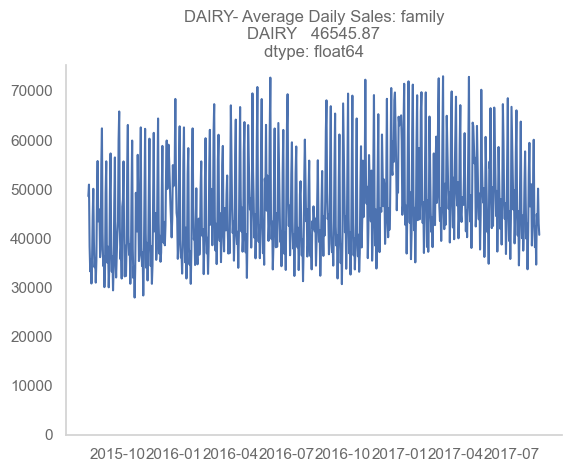

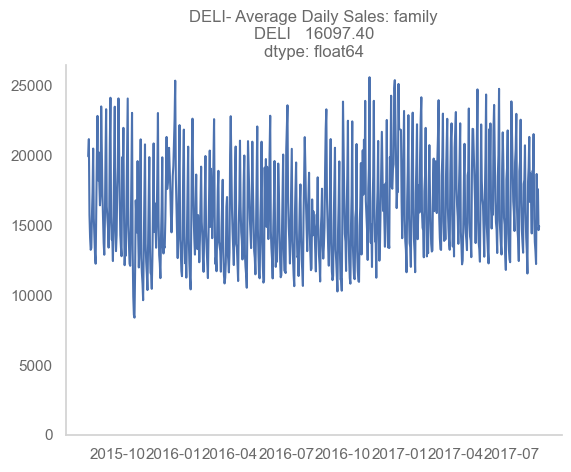

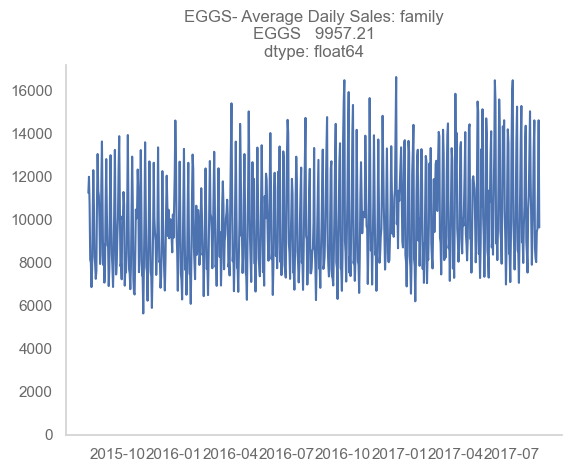

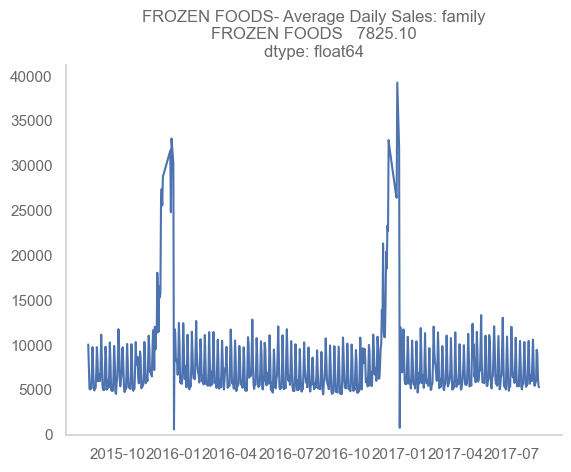

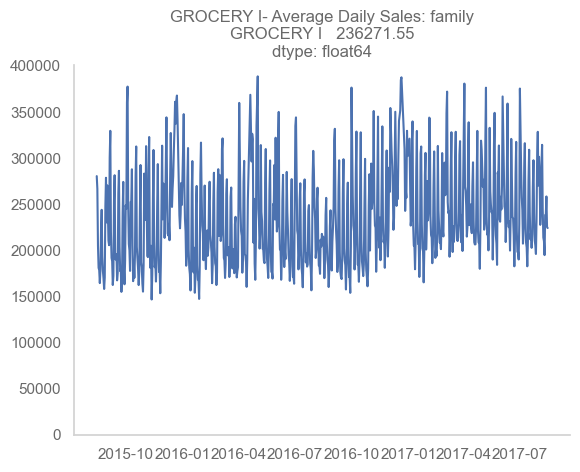

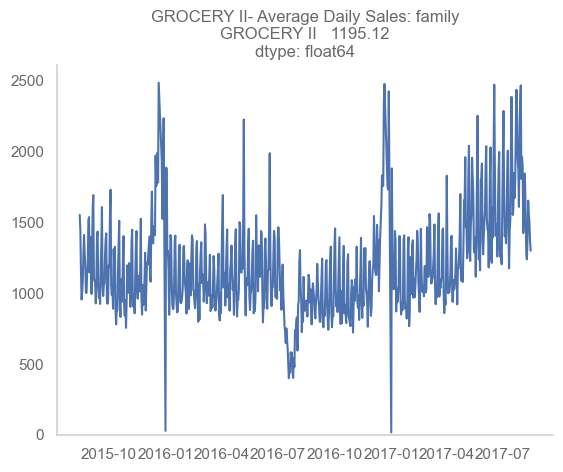

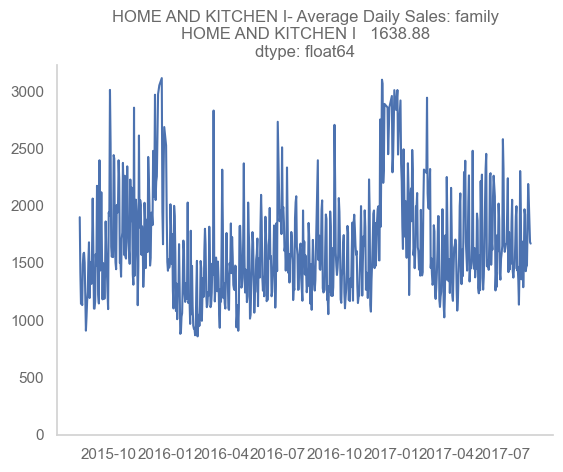

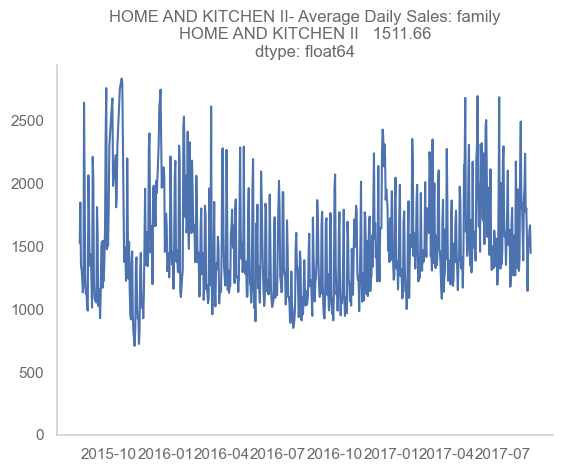

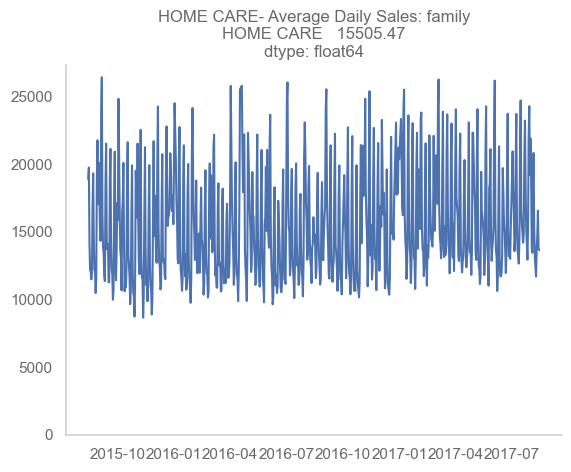

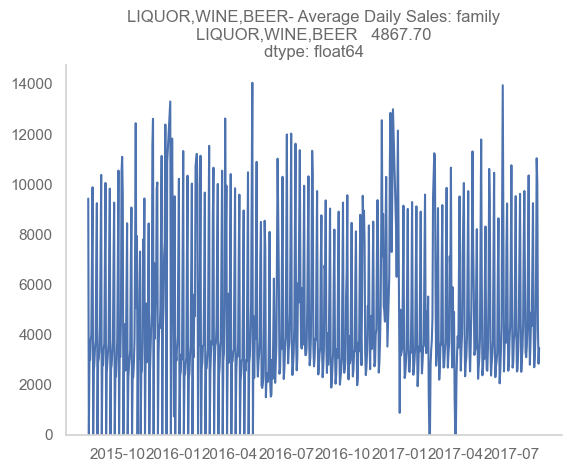

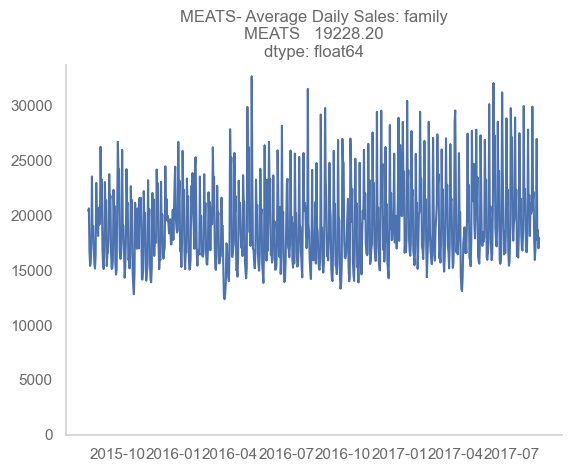

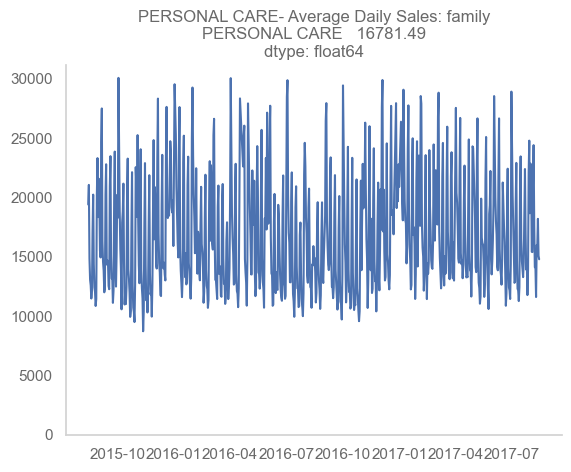

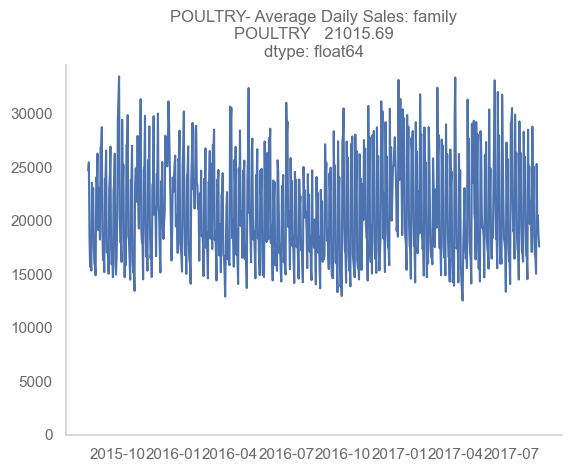

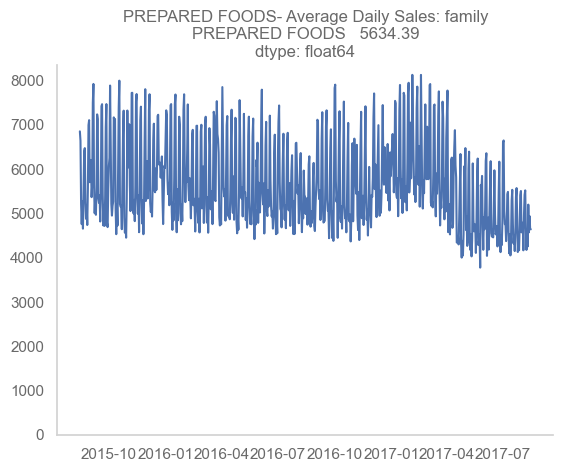

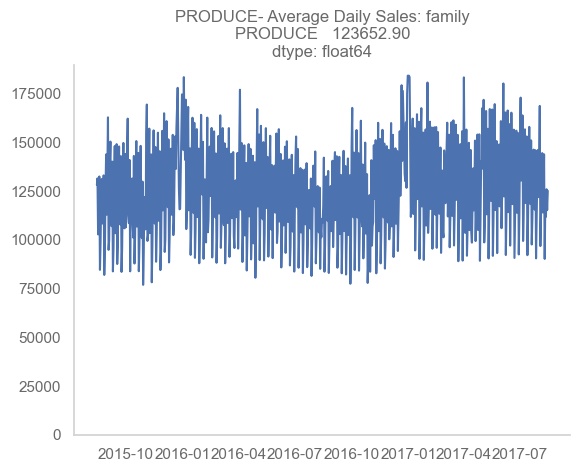

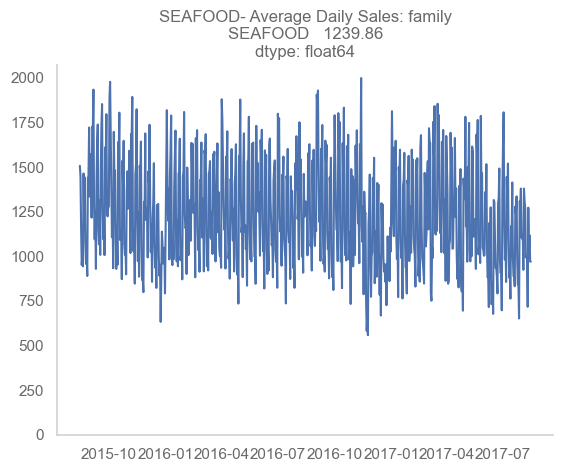

In [21]:
for i in range(len(prediction_df_list)):
    plt.plot(prediction_df_list[i])
    plt.title(prediction_df_list[i].columns[0]+'- Average Daily Sales: '+str(prediction_df_list[i].mean()))
    plt.ylim(ymin=0)
    plt.show()

In [22]:
avg_daily_sales = combined_df.apply(np.mean, axis=0).sort_values()
low, mid = np.percentile(combined_df.apply(np.mean, axis=0).sort_values(),[33,66])

In [23]:
low_vol_columns = avg_daily_sales[avg_daily_sales<=low].index.tolist()
mid_vol_columns = avg_daily_sales[(avg_daily_sales>low) & (avg_daily_sales<mid)].index.tolist()
high_vol_columns = avg_daily_sales[avg_daily_sales>=mid].index.tolist()

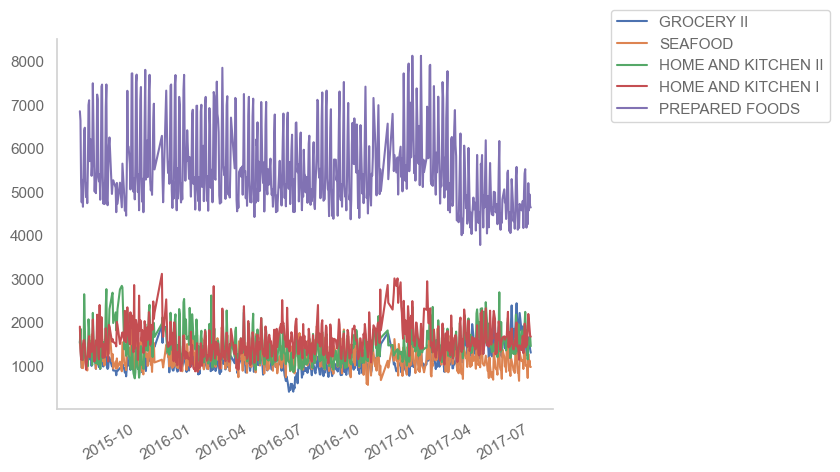

In [24]:
#total_sales_df[low_vol_columns].plot.line()
plt.plot(combined_df[low_vol_columns].drop(columns='LIQUOR,WINE,BEER'))
low_vol_columns.remove('LIQUOR,WINE,BEER')
plt.legend(low_vol_columns, loc='best', bbox_to_anchor=(1.1, 1.1))
plt.xticks(rotation=30)
plt.show()

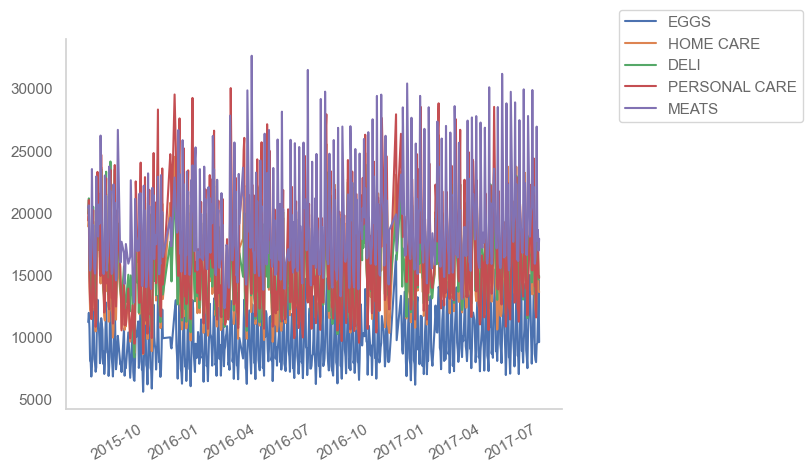

In [25]:
plt.plot(combined_df[mid_vol_columns].drop(columns='FROZEN FOODS'))
mid_vol_columns.remove('FROZEN FOODS')
plt.legend(mid_vol_columns, loc='best', bbox_to_anchor=(1.1, 1.1))
plt.xticks(rotation=30)
plt.show()

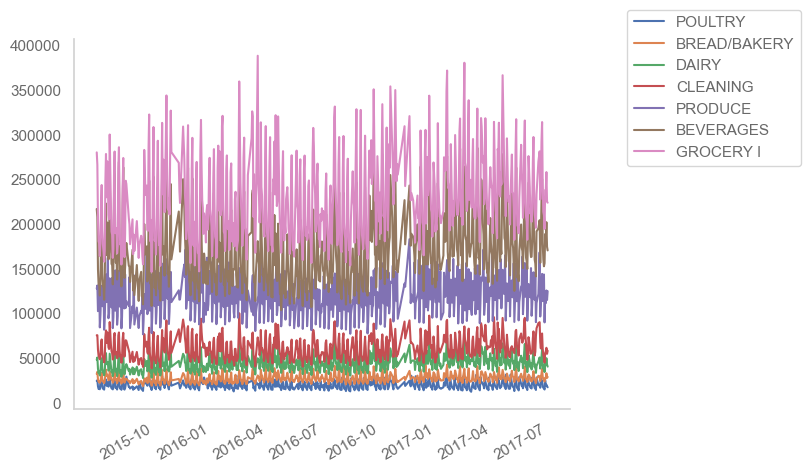

In [26]:
plt.plot(combined_df[high_vol_columns])
plt.legend(high_vol_columns, loc='best', bbox_to_anchor=(1.1, 1.1))
plt.xticks(rotation=30)
plt.show()

In [27]:
combined_df.head()

family,BEVERAGES,BREAD/BAKERY,CLEANING,DAIRY,DELI,EGGS,FROZEN FOODS,GROCERY I,GROCERY II,HOME AND KITCHEN I,HOME AND KITCHEN II,HOME CARE,"LIQUOR,WINE,BEER",MEATS,PERSONAL CARE,POULTRY,PREPARED FOODS,PRODUCE,SEAFOOD
date,,,,,,,,,,,,,,,,,,,
2015-08-15,217135.00,32509.91,75837.00,48578.00,19946.92,11232.00,10075.02,280491.48,1552.00,1899.00,1526.00,18924.00,9423.00,20403.94,19398.00,24718.80,6854.54,128147.18,1507.24
2015-08-16,208213.00,34851.88,75824.00,50930.00,21178.46,11977.00,7526.03,266657.28,1441.00,1418.00,1850.00,19757.00,0.00,20616.16,21048.00,25480.78,6640.39,131493.93,1448.72
2015-08-17,149741.00,26361.77,59718.00,38358.00,15755.02,10713.00,5145.30,205150.61,1161.00,1143.00,1343.00,14120.00,2968.00,16725.03,14854.00,18549.11,5212.50,102769.60,1166.22
2015-08-18,132609.00,23915.95,52749.00,33273.00,14119.25,8123.00,5050.99,181016.01,955.00,1181.00,1320.00,12202.00,2984.00,15377.12,13064.00,15722.33,4758.13,106468.23,951.63
2015-08-19,131368.00,23995.15,51157.00,35760.00,13250.04,8001.00,5372.18,178550.63,1011.00,1132.00,1249.00,12042.00,3786.00,15654.35,12581.00,16360.62,5275.08,132449.58,996.73


In [28]:
combined_df = combined_df.drop(columns=['LIQUOR,WINE,BEER', 'FROZEN FOODS'])
print(combined_df.columns)

Index(['BEVERAGES', 'BREAD/BAKERY', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'GROCERY I', 'GROCERY II', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II',
       'HOME CARE', 'MEATS', 'PERSONAL CARE', 'POULTRY', 'PREPARED FOODS',
       'PRODUCE', 'SEAFOOD'],
      dtype='object', name='family')


###HYPERPARAMETER TUNING AND BACKTESTING PIPELINE
Ranges give on Prophet's documentation

1. changepoint_prior_scale [0.001, 0.5]
2. seasonality_prior_scale [0.01, 10]
3. holidays_prior_scale [0.01, 10]
4. seasonality_mode ['additive', 'multiplicative'].
5. changepoint_range [0.5, 0.95]

https://facebook.github.io/prophet/docs/diagnostics.html

In [29]:
changepoint_prior_scale_range = [0.001, 0.01, 0.1, 0.5]
seasonality_prior_scale_range = np.linspace(0.01, 10, num=5).tolist()
holidays_prior_scale_range = np.linspace(0.01, 10, num=5).tolist()

In [30]:
start_time = time.time()

dicts = {}

for feature in combined_df.columns:
  
    category_df = combined_df[feature].copy().reset_index()
    category_df.columns = ["ds", "y"]

    category_df[["y"]] = category_df[["y"]].apply(pd.to_numeric)
    category_df["ds"] = pd.to_datetime(category_df["ds"])
    
    param_grid = {  
        "changepoint_prior_scale": changepoint_prior_scale_range,
        "seasonality_prior_scale": seasonality_prior_scale_range,
        'holidays_prior_scale': holidays_prior_scale_range}
        #'seasonality_mode': seasonality_mode_options,
        #'changepoint_range': changepoint_range_range,

    # Generate all combinations of parameters
    all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
    mapes = [] 

    # Use cross validation to evaluate all parameters
    for params in all_params:
        m = Prophet(**params).fit(category_df)  # Fit model with given params
        df_cv = cross_validation(m, initial="365 days", period="30 days", horizon = "30 days") #took parallel out
        df_p = performance_metrics(df_cv, rolling_window=1)
        print(df_p)
        mapes.append(df_p["mape"].values[0])

    # Find the best parameters
    tuning_results = pd.DataFrame(all_params)
    tuning_results["mape"] = mapes
    
    print(feature)
    print(tuning_results.head())
    params_dict = dict(tuning_results.sort_values("mape").reset_index(drop=True).iloc[0])
    params_dict["column"] = feature 
    
    dicts[feature] = params_dict

print("--- %s seconds ---" % (time.time() - start_time))

16:19:25 - cmdstanpy - INFO - Chain [1] start processing
16:19:26 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/12 [00:00<?, ?it/s]

16:19:26 - cmdstanpy - INFO - Chain [1] start processing
16:19:26 - cmdstanpy - INFO - Chain [1] done processing
16:19:26 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:19:26 - cmdstanpy - INFO - Chain [1] start processing
16:19:28 - cmdstanpy - INFO - Chain [1] done processing
16:19:28 - cmdstanpy - INFO - Chain [1] start processing
16:19:28 - cmdstanpy - INFO - Chain [1] done processing
16:19:28 - cmdstanpy - INFO - Chain [1] start processing
16:19:28 - cmdstanpy - INFO - Chain [1] done processing
16:19:28 - cmdstanpy - INFO - Chain [1] start processing
16:19:28 - cmdstanpy - INFO - Chain [1] done processing
16:19:28 - cmdstanpy - INFO - Chain [1] start processing
16:19:28 - cmdstanpy - INFO - Chain [1] done processing
16:19:28 - cmdstanpy - INFO - Chain [1] start processing
16:19:28 - cmdstanpy - INFO - Chain [1] done processing
16:19:28 - cmdstanpy - ERROR - Chain [1] error: error

  horizon           mse     rmse      mae  mape  mdape  smape  coverage
0 30 days 1568902853.32 39609.38 29259.92  0.16   0.12   0.18      0.57


  0%|          | 0/12 [00:00<?, ?it/s]

...

17:04:48 - cmdstanpy - INFO - Chain [1] start processing
17:04:48 - cmdstanpy - INFO - Chain [1] done processing
17:04:48 - cmdstanpy - INFO - Chain [1] start processing
17:04:48 - cmdstanpy - INFO - Chain [1] done processing
17:04:48 - cmdstanpy - INFO - Chain [1] start processing
17:04:48 - cmdstanpy - INFO - Chain [1] done processing
17:04:48 - cmdstanpy - INFO - Chain [1] start processing
17:04:48 - cmdstanpy - INFO - Chain [1] done processing
17:04:48 - cmdstanpy - INFO - Chain [1] start processing
17:04:48 - cmdstanpy - INFO - Chain [1] done processing
17:04:48 - cmdstanpy - INFO - Chain [1] start processing
17:04:48 - cmdstanpy - INFO - Chain [1] done processing
17:04:48 - cmdstanpy - INFO - Chain [1] start processing
17:04:48 - cmdstanpy - INFO - Chain [1] done processing
17:04:48 - cmdstanpy - INFO - Chain [1] start processing
17:04:48 - cmdstanpy - INFO - Chain [1] done processing
17:04:48 - cmdstanpy - INFO - Chain [1] start processing
17:04:48 - cmdstanpy - INFO - Chain [1]

  horizon      mse   rmse    mae  mape  mdape  smape  coverage
0 30 days 30051.81 173.35 136.97  0.13   0.10   0.12      0.70


  0%|          | 0/12 [00:00<?, ?it/s]

17:04:49 - cmdstanpy - INFO - Chain [1] start processing
17:04:49 - cmdstanpy - INFO - Chain [1] done processing
17:04:49 - cmdstanpy - INFO - Chain [1] start processing
17:04:49 - cmdstanpy - INFO - Chain [1] done processing
17:04:49 - cmdstanpy - INFO - Chain [1] start processing
17:04:49 - cmdstanpy - INFO - Chain [1] done processing
17:04:49 - cmdstanpy - INFO - Chain [1] start processing
17:04:49 - cmdstanpy - INFO - Chain [1] done processing
17:04:49 - cmdstanpy - INFO - Chain [1] start processing
17:04:49 - cmdstanpy - INFO - Chain [1] done processing
17:04:49 - cmdstanpy - INFO - Chain [1] start processing
17:04:49 - cmdstanpy - INFO - Chain [1] done processing
17:04:49 - cmdstanpy - INFO - Chain [1] start processing
17:04:49 - cmdstanpy - INFO - Chain [1] done processing
17:04:49 - cmdstanpy - INFO - Chain [1] start processing
17:04:49 - cmdstanpy - INFO - Chain [1] done processing
17:04:49 - cmdstanpy - INFO - Chain [1] start processing
17:04:49 - cmdstanpy - INFO - Chain [1]

  horizon      mse   rmse    mae  mape  mdape  smape  coverage
0 30 days 30051.81 173.35 136.97  0.13   0.10   0.12      0.69
SEAFOOD
   changepoint_prior_scale  seasonality_prior_scale  holidays_prior_scale  \
0                     0.00                     0.01                  0.01   
1                     0.00                     0.01                  2.51   
2                     0.00                     0.01                  5.00   
3                     0.00                     0.01                  7.50   
4                     0.00                     0.01                 10.00   

   mape  
0  0.12  
1  0.12  
2  0.12  
3  0.12  
4  0.12  
--- 2724.321477174759 seconds ---


In [31]:
print(dicts.keys())

dict_keys(['BEVERAGES', 'BREAD/BAKERY', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'GROCERY I', 'GROCERY II', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME CARE', 'MEATS', 'PERSONAL CARE', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SEAFOOD'])


In [32]:
print(dicts)

{'BEVERAGES': {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 7.5024999999999995, 'mape': 0.09487725316572597, 'column': 'BEVERAGES'}, 'BREAD/BAKERY': {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 7.5024999999999995, 'mape': 0.06500256899722101, 'column': 'BREAD/BAKERY'}, 'CLEANING': {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 2.5075, 'mape': 0.10372052621347616, 'column': 'CLEANING'}, 'DAIRY': {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 2.5075, 'holidays_prior_scale': 0.01, 'mape': 0.06837969179643011, 'column': 'DAIRY'}, 'DELI': {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 2.5075, 'holidays_prior_scale': 0.01, 'mape': 0.10036495397722, 'column': 'DELI'}, 'EGGS': {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 2.5075, 'holidays_prior_scale': 0.01, 'mape': 0.0793983798375152, 'column': 'EGGS'}, 'GROCERY I': {'ch

####HOLIDAY DATA

In [33]:
#adding holiday data

holiday = pd.DataFrame([])

ecuador_holidays = holidays.EC()  # this is a dict
# the below is the same, but takes a string:
ecuador_holidays = holidays.country_holidays('EC')  # this is a dict


for date_, name in sorted(holidays.EC(years=[2015,2016,2017,2018]).items()):
    holiday = pd.concat([holiday, pd.DataFrame({'ds': date_, 'holiday': "EC-Holidays", 'lower_window': -2, 'upper_window': 1}, index=[0])], ignore_index=True) 

holiday['ds'] = pd.to_datetime(holiday['ds'], format='%Y-%m-%d', errors='ignore')
holiday.head()

/var/folders/km/6m6wt0n50mjdjd15836087r40000gn/T/ipykernel_72994/1667473210.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  holiday['ds'] = pd.to_datetime(holiday['ds'], format='%Y-%m-%d', errors='ignore')


,ds,holiday,lower_window,upper_window
0,2015-01-01,EC-Holidays,-2,1
1,2015-02-16,EC-Holidays,-2,1
2,2015-02-17,EC-Holidays,-2,1
3,2015-04-03,EC-Holidays,-2,1
4,2015-05-01,EC-Holidays,-2,1


###BACKTESTING WITH TUNED METRICS LATEST MONTH UP-TO-DATE MAPE

In [34]:
prediction_days = 30
forecast_start_date = max(combined_df.index) - timedelta(prediction_days)

In [35]:
#PROPHET MODEL

forecasted_dfs = []

for feature in combined_df.columns:
    
    #formatting
    df_copy = combined_df[feature].copy().reset_index()
    df_copy.columns = ['ds','y']
    df_copy[['y']] = df_copy[['y']].apply(pd.to_numeric)

    df_copy['ds'] = pd.to_datetime(df_copy['ds'])
    
    df_copy_ = df_copy[df_copy['ds'] < forecast_start_date]
    
    #finding the right params_dict for this category
    params_dict = dicts[feature]
    
    #model
    m = Prophet(changepoint_prior_scale = dicts[feature]['changepoint_prior_scale'],
                seasonality_prior_scale = dicts[feature]['seasonality_prior_scale'],
                holidays_prior_scale = dicts[feature]['holidays_prior_scale'],
                seasonality_mode = 'multiplicative',
                #changepoint_range= len(df_copy/365),
                holidays=holiday
                 )
    
    m.fit(df_copy_)

    future = m.make_future_dataframe(periods=prediction_days)
    fcst_prophet_train = m.predict(future)
    
    filter = fcst_prophet_train['ds']>=forecast_start_date 
    predicted_df = fcst_prophet_train[filter][['ds','yhat']]
    predicted_df = predicted_df.merge(df_copy)

    print(feature,mape(predicted_df['y'],predicted_df['yhat']))

17:04:50 - cmdstanpy - INFO - Chain [1] start processing
17:04:50 - cmdstanpy - INFO - Chain [1] done processing
17:04:50 - cmdstanpy - INFO - Chain [1] start processing
17:04:50 - cmdstanpy - INFO - Chain [1] done processing
17:04:50 - cmdstanpy - INFO - Chain [1] start processing


BEVERAGES 7.6513154112920825
BREAD/BAKERY 5.543249079086105


17:04:50 - cmdstanpy - INFO - Chain [1] done processing
17:04:50 - cmdstanpy - INFO - Chain [1] start processing
17:04:50 - cmdstanpy - INFO - Chain [1] done processing
17:04:51 - cmdstanpy - INFO - Chain [1] start processing


CLEANING 19.31947637753764
DAIRY 8.242400940720492


17:04:51 - cmdstanpy - INFO - Chain [1] done processing
17:04:51 - cmdstanpy - INFO - Chain [1] start processing
17:04:51 - cmdstanpy - INFO - Chain [1] done processing
17:04:51 - cmdstanpy - INFO - Chain [1] start processing
17:04:51 - cmdstanpy - INFO - Chain [1] done processing


...

HOME CARE 11.729693193638372
MEATS 5.744923963976057


17:04:52 - cmdstanpy - INFO - Chain [1] start processing
17:04:52 - cmdstanpy - INFO - Chain [1] done processing
17:04:52 - cmdstanpy - INFO - Chain [1] start processing


PERSONAL CARE 9.83192701650117
POULTRY 7.4986053391455645


17:04:52 - cmdstanpy - INFO - Chain [1] done processing
17:04:52 - cmdstanpy - INFO - Chain [1] start processing
17:04:52 - cmdstanpy - INFO - Chain [1] done processing
17:04:52 - cmdstanpy - INFO - Chain [1] start processing
17:04:52 - cmdstanpy - INFO - Chain [1] done processing


PREPARED FOODS 11.53282872813508
PRODUCE 5.094066566766478
SEAFOOD 13.755001609951488


In [36]:
final_results = []

for feature in combined_df.columns:
    
    df_copy = combined_df[feature].copy().reset_index()
    df_copy.columns = ['ds', 'y']
    df_copy['y'] = pd.to_numeric(df_copy['y'])
    df_copy['ds'] = pd.to_datetime(df_copy['ds'])

    df_train = df_copy[df_copy['ds'] < forecast_start_date]
    df_test = df_copy[df_copy['ds'] >= forecast_start_date]

    params_dict = dicts[feature]

    m = Prophet(
        changepoint_prior_scale=params_dict['changepoint_prior_scale'],
        seasonality_prior_scale=params_dict['seasonality_prior_scale'],
        holidays_prior_scale=params_dict['holidays_prior_scale'],
        seasonality_mode='multiplicative',
        holidays=holiday
    )

    m.fit(df_train)

    future = m.make_future_dataframe(periods=prediction_days)
    forecast = m.predict(future)

    # Filter forecast to test range
    forecast_filtered = forecast[forecast['ds'] >= forecast_start_date][['ds', 'yhat']].copy()
    forecast_filtered = forecast_filtered.merge(df_test, on='ds', how='left')
    forecast_filtered['family'] = feature
    forecast_filtered['mape'] = mape(forecast_filtered['y'], forecast_filtered['yhat'])

    final_results.append(forecast_filtered)

# Combine all results
final_df = pd.concat(final_results)
final_df.to_csv('forecast_results_by_family.csv', index=False)

17:04:52 - cmdstanpy - INFO - Chain [1] start processing
17:04:52 - cmdstanpy - INFO - Chain [1] done processing
17:04:52 - cmdstanpy - INFO - Chain [1] start processing
17:04:53 - cmdstanpy - INFO - Chain [1] done processing
17:04:53 - cmdstanpy - INFO - Chain [1] start processing
17:04:53 - cmdstanpy - INFO - Chain [1] done processing
17:04:53 - cmdstanpy - INFO - Chain [1] start processing
17:04:53 - cmdstanpy - INFO - Chain [1] done processing
17:04:53 - cmdstanpy - INFO - Chain [1] start processing
17:04:53 - cmdstanpy - INFO - Chain [1] done processing
17:04:53 - cmdstanpy - INFO - Chain [1] start processing
17:04:53 - cmdstanpy - INFO - Chain [1] done processing
17:04:53 - cmdstanpy - INFO - Chain [1] start processing
17:04:53 - cmdstanpy - INFO - Chain [1] done processing
17:04:53 - cmdstanpy - INFO - Chain [1] start processing
17:04:53 - cmdstanpy - INFO - Chain [1] done processing
17:04:53 - cmdstanpy - INFO - Chain [1] start processing
17:04:53 - cmdstanpy - INFO - Chain [1]

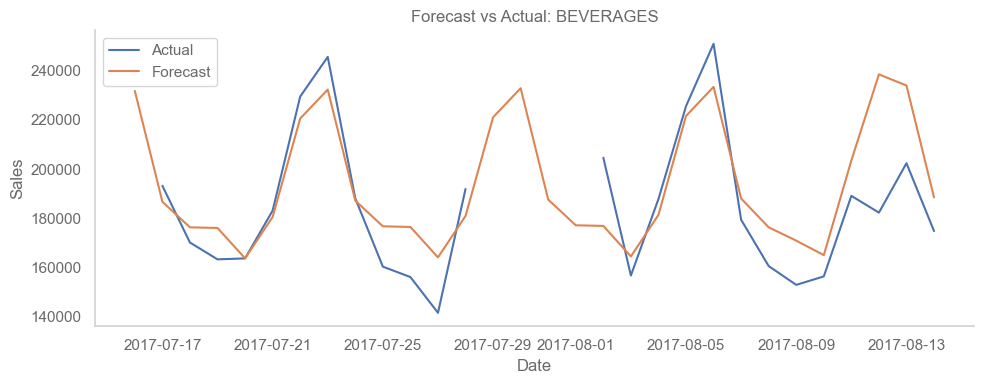

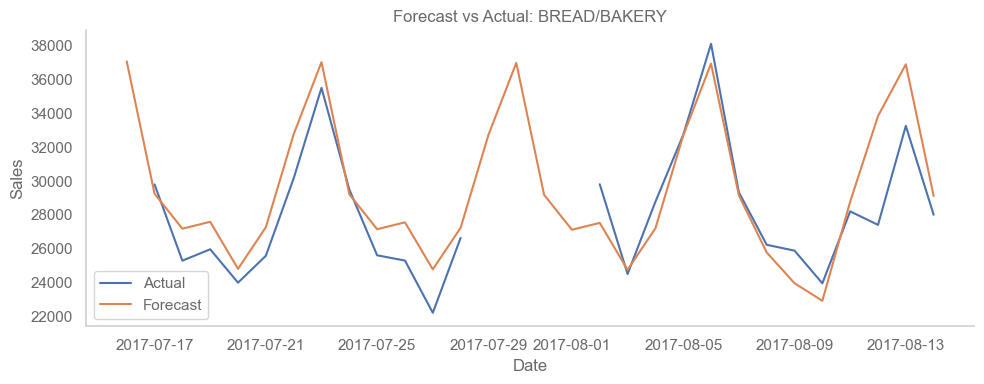

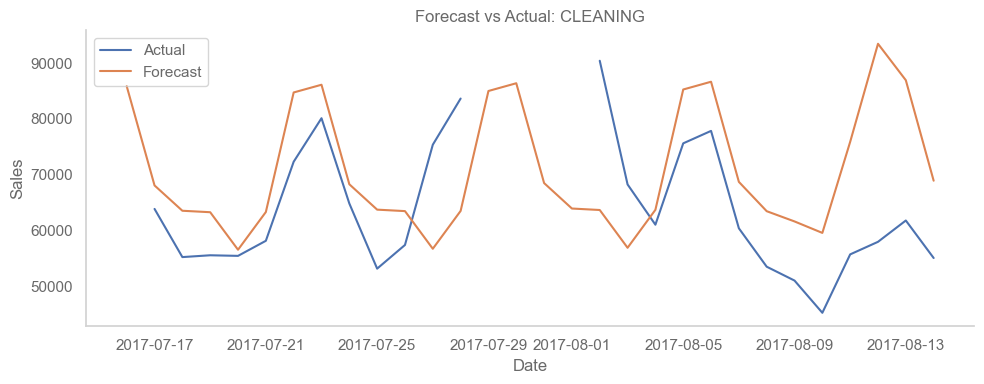

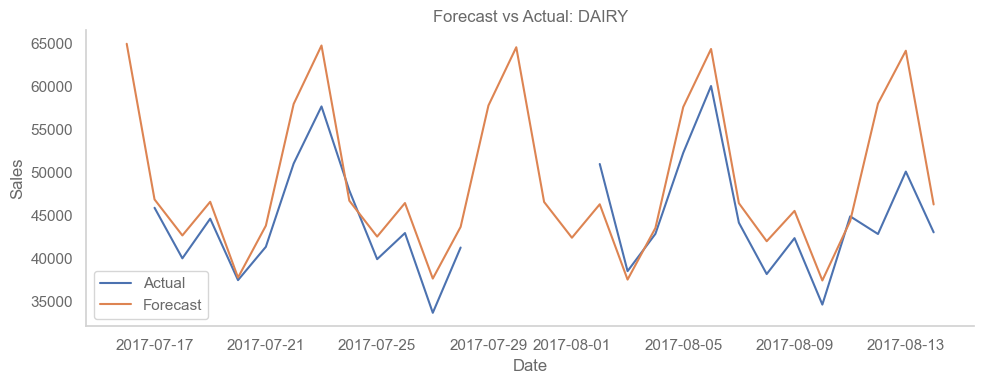

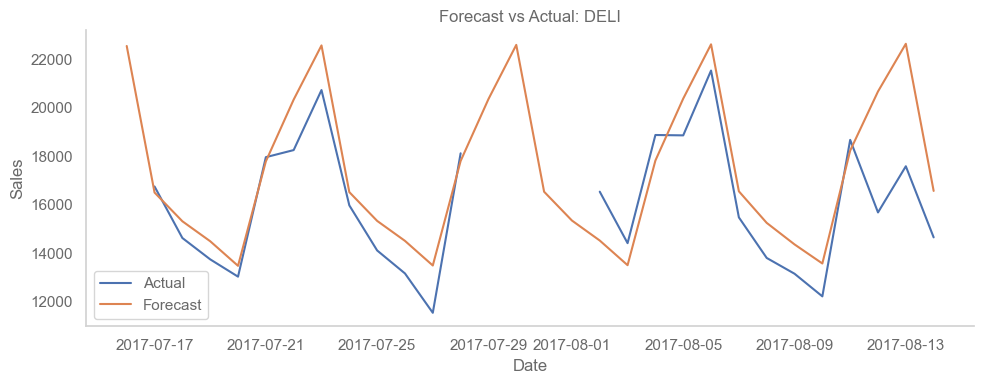

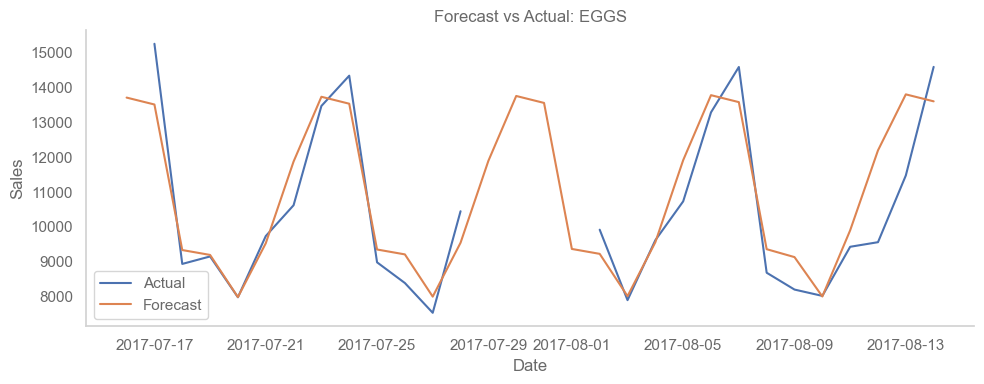

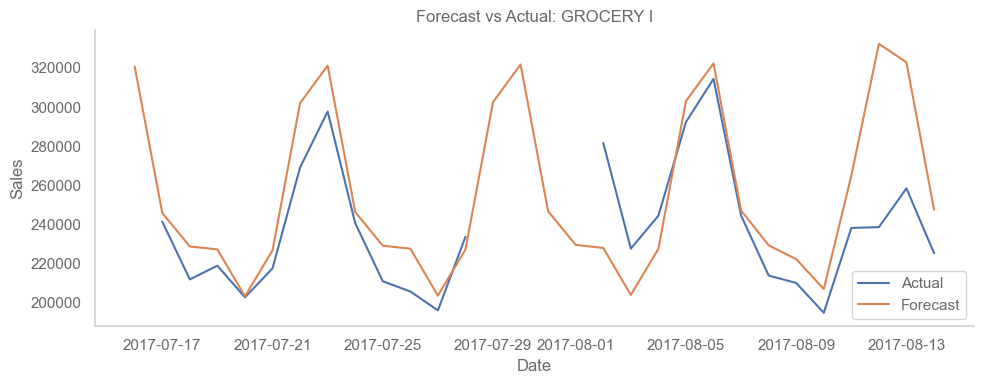

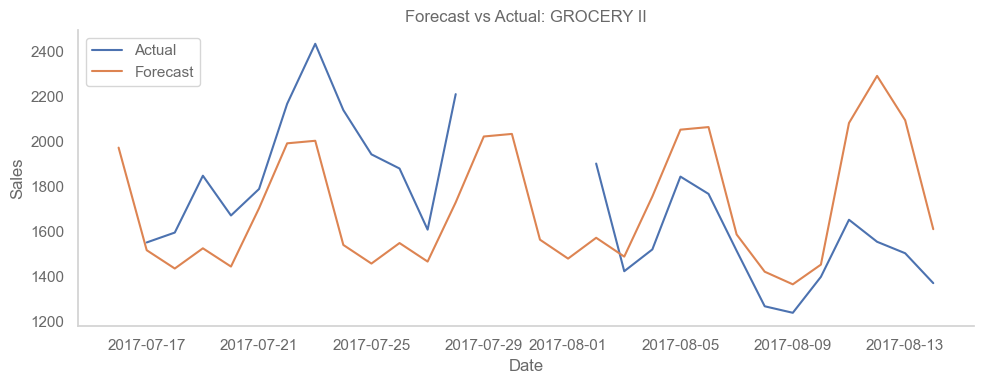

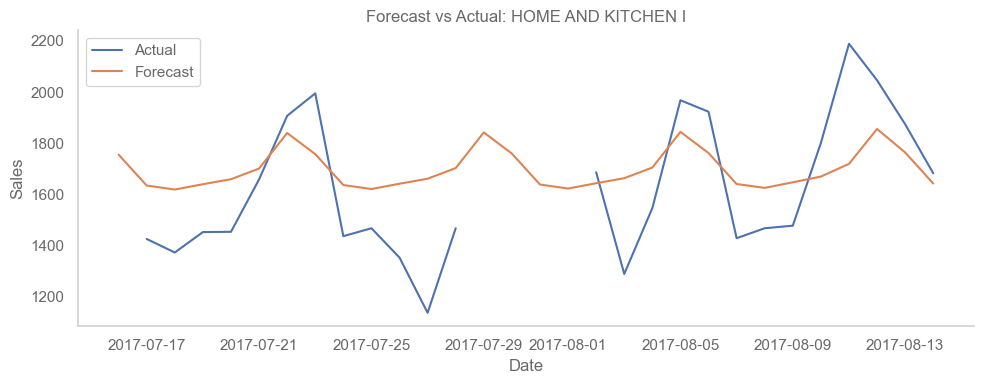

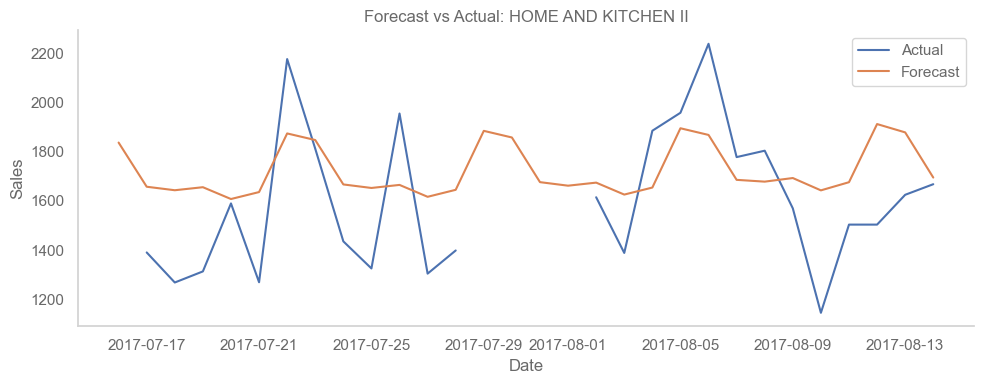

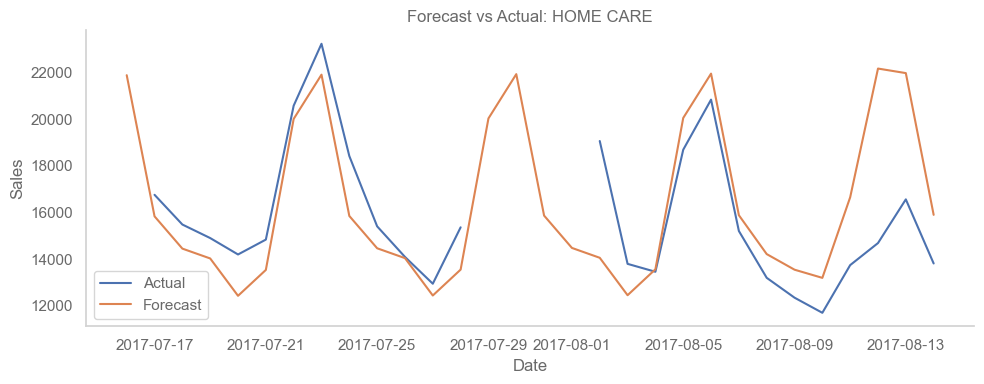

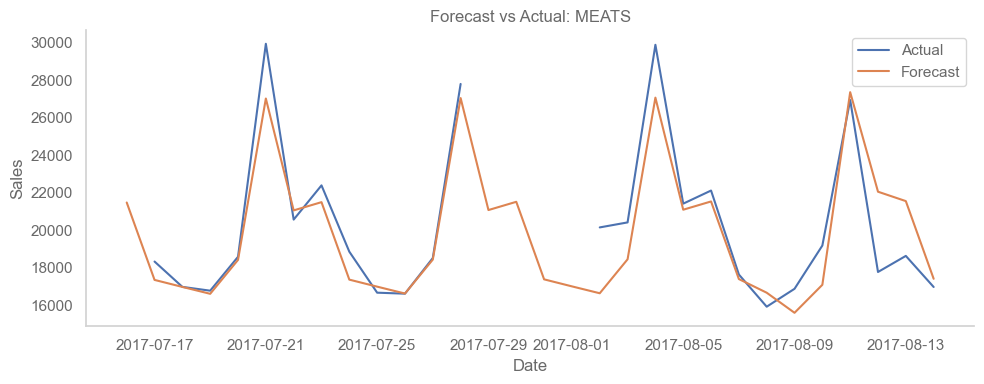

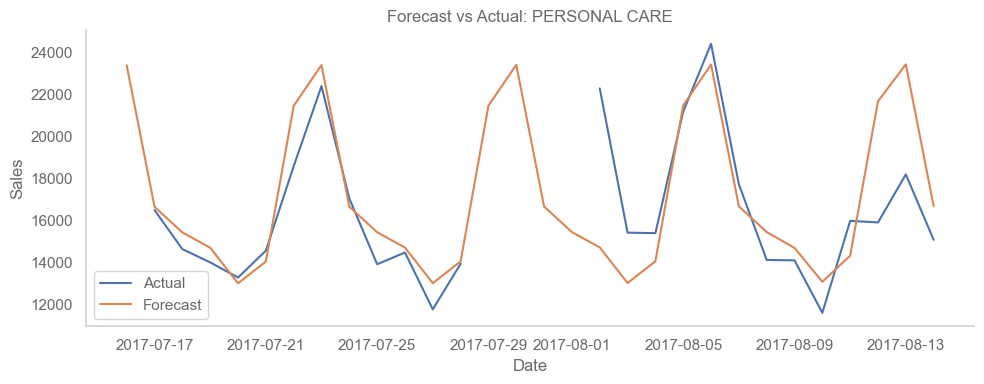

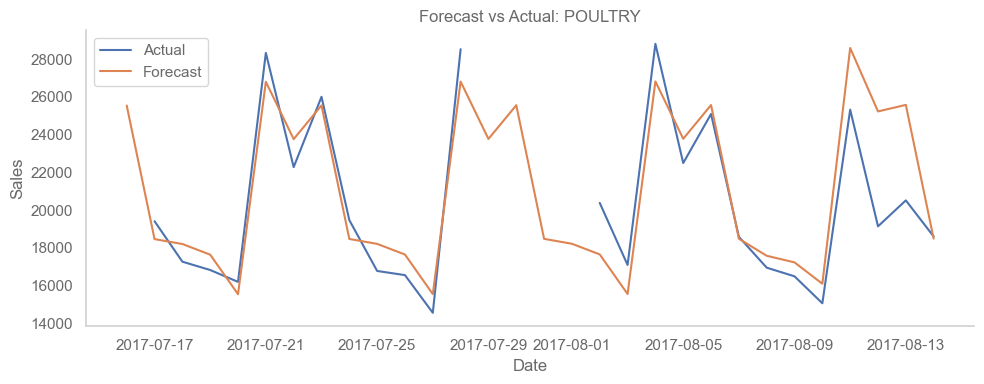

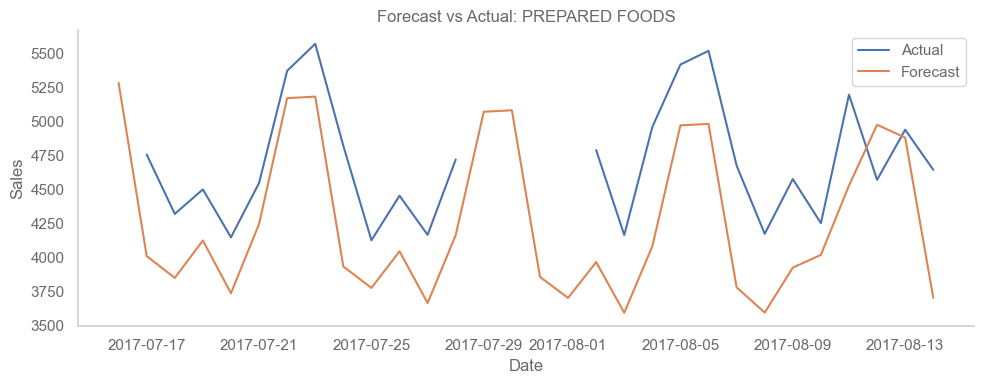

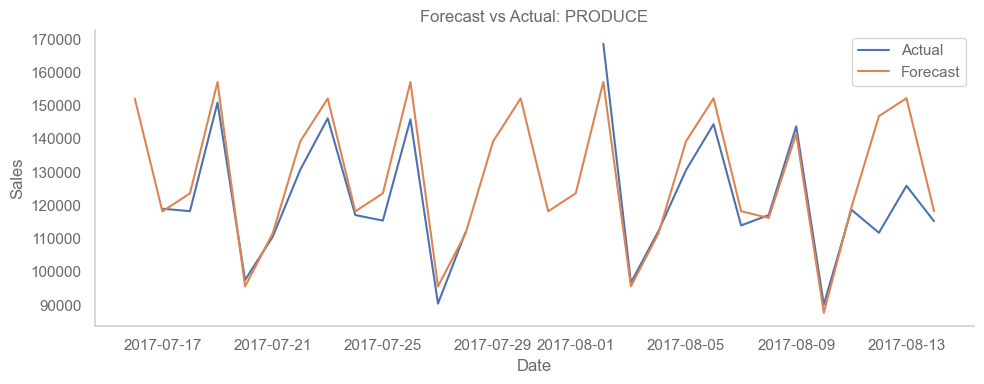

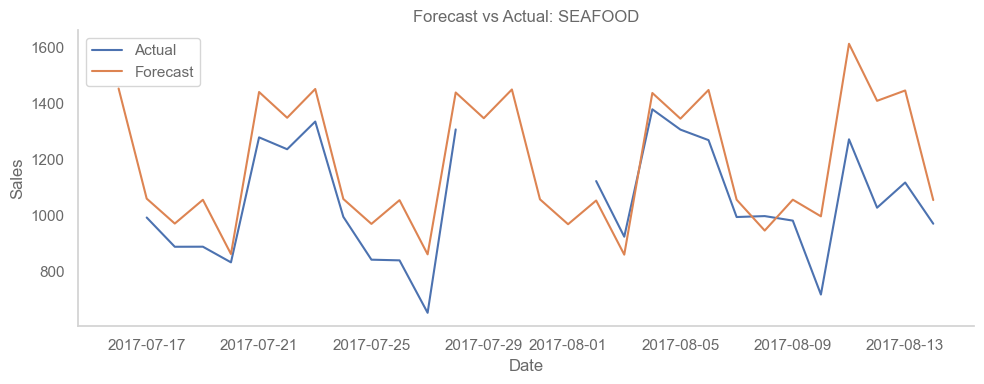

In [37]:
sample_families = final_df['family'].unique()

for fam in sample_families:
    plot_df = final_df[final_df['family'] == fam]
    plt.figure(figsize=(10, 4))
    plt.plot(plot_df['ds'], plot_df['y'], label='Actual')
    plt.plot(plot_df['ds'], plot_df['yhat'], label='Forecast')
    plt.title(f"Forecast vs Actual: {fam}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()
